🚀 پروژه تشخیص خرابی بیرینگ - ۵ فاز کامل

📊 فاز ۱: پاک‌سازی و پیش‌پردازش اولیه

📊 داده خام: (1384, 9)

🚨 پاکسازی Outlier:
✅ نمونه اولیه: 1384 → نهایی: 1307
✅ درصد حذف: 5.6%
✅ ذخیره شد: vibration_data_clean.csv

🔧 فاز ۲: مهندسی ویژگی و تحلیل اکتشافی
📊 داده ورودی: (1307, 9)

🔹 ویژگی‌های نسبت‌ها...
🔹 ویژگی‌های انرژی و شدت...
🔹 ویژگی‌های آماری ترکیبی...
🔹 لگاریتم ویژگی‌ها...
🔹 ویژگی‌های هشدار سریع...
🔹 ویژگی‌های تفکیک‌کننده کلاس ۲...
🔹 ویژگی‌های فرکانسی...

🔍 بررسی همبستگی و حذف ویژگی‌های هم‌خط...
✅ 8 ویژگی هم‌خط حذف شد:
   - Vel, Peak (RMS)
   - Acc, Rms (RMS)_log
   - Kurt (RMS)
   - Freq_Harmonic_3
   - Freq_Harmonic_2
   - Vel_x_Crest
   - Vel, Rms (RMS)
   - Crest (RMS)

🔥 رسم Heatmap نهایی...


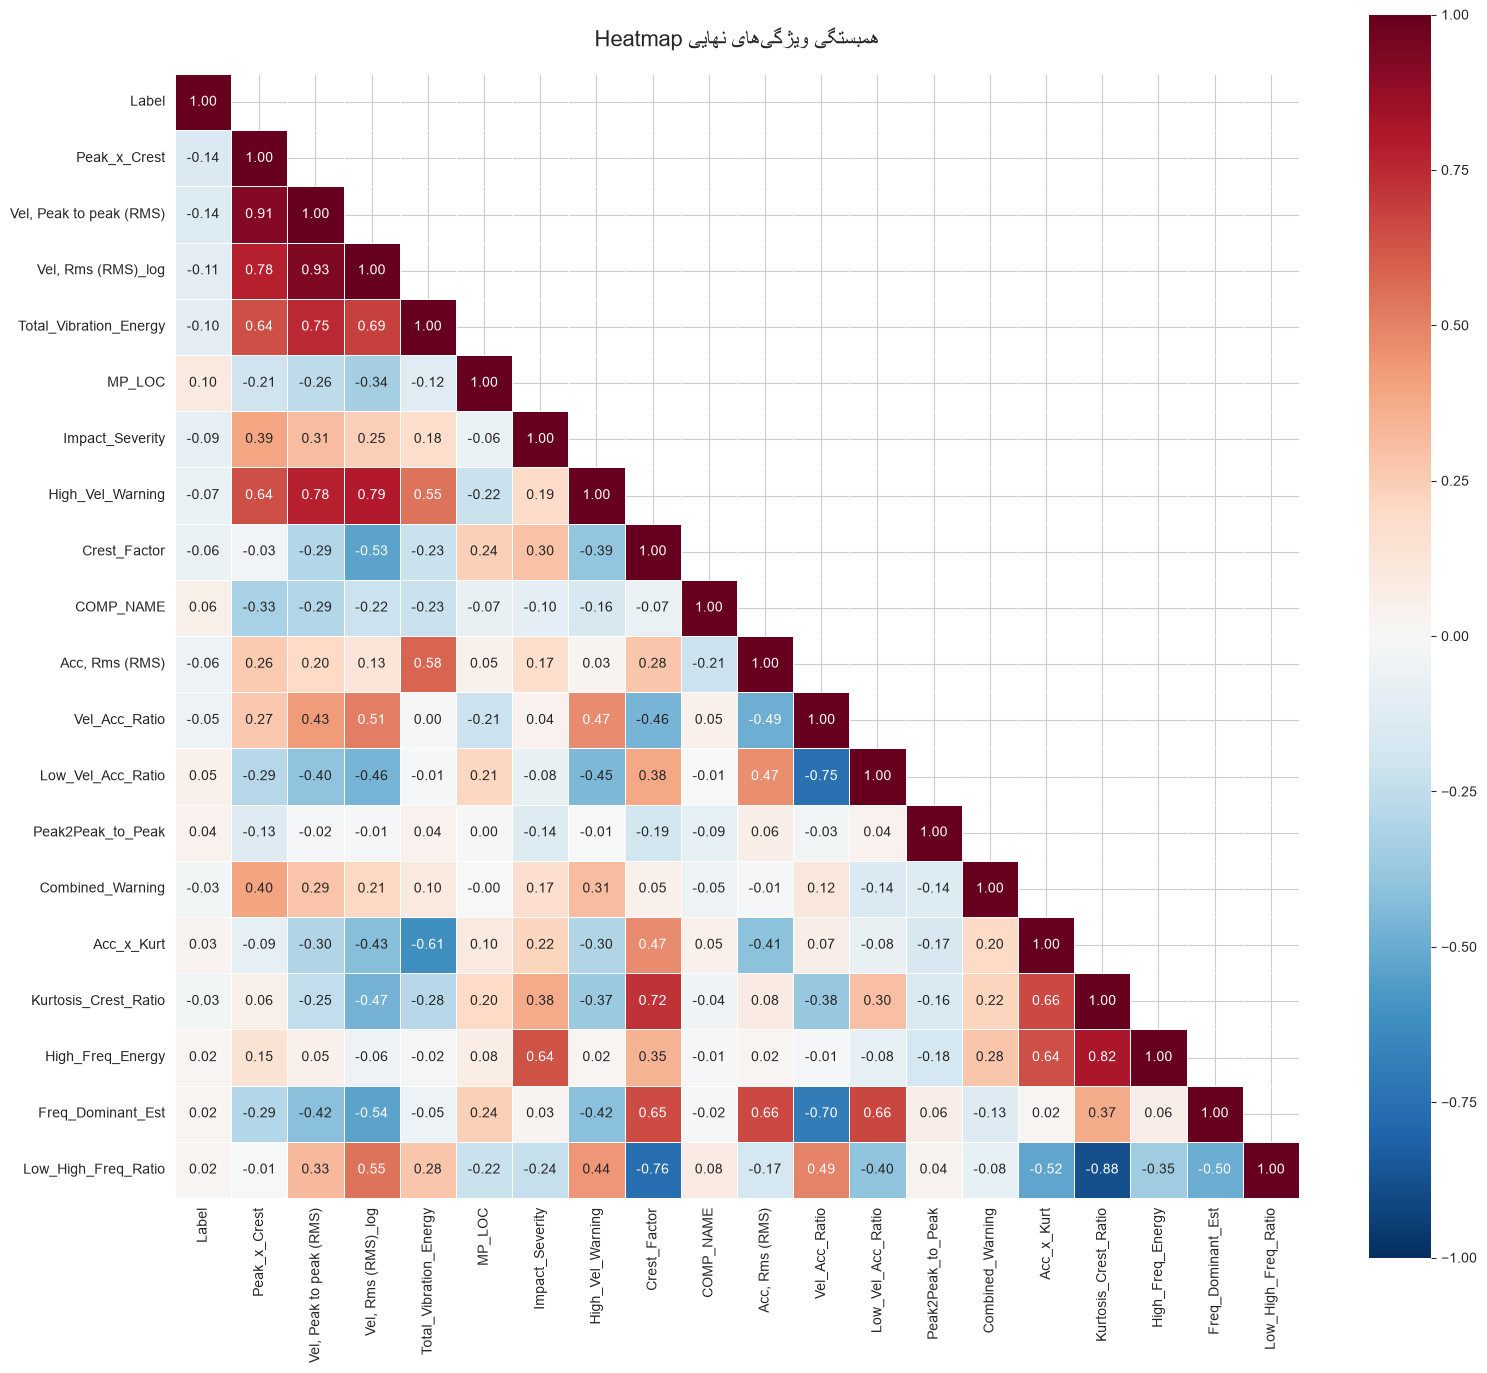

✅ ذخیره شد: heatmap_final.png

✅ ذخیره شد: vibration_data_with_features.csv
📊 تعداد ویژگی‌های نهایی: 23

📊 فاز ۳: آماده‌سازی داده و تقسیم‌بندی
📊 داده کامل: (1307, 24)
✅ ویژگی‌ها: 23 ستون
✅ برچسب‌ها: 3 کلاس

✅ تقسیم‌بندی:
   Train: 783 نمونه
   Validation: 262 نمونه
   Test: 262 نمونه
   Train توزیع: {np.int64(0): np.int64(292), np.int64(1): np.int64(291), np.int64(2): np.int64(200)}
   Validation توزیع: {np.int64(0): np.int64(98), np.int64(1): np.int64(97), np.int64(2): np.int64(67)}
   Test توزیع: {np.int64(0): np.int64(98), np.int64(1): np.int64(97), np.int64(2): np.int64(67)}

🎯 فاز ۴: آموزش مدل XGBoost و تنظیم آستانه

🚀 آموزش مدل...
[0]	train-mlogloss:1.03962	val-mlogloss:1.05713
[50]	train-mlogloss:0.32363	val-mlogloss:0.82290
[95]	train-mlogloss:0.15927	val-mlogloss:0.83677
✅ آموزش کامل شد

📊 عملکرد اولیه روی Validation:
              precision    recall  f1-score   support

      کلاس ۰       0.67      0.73      0.70        98
      کلاس ۱       0.63      0.65      0.64        9

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🚀 پروژه تشخیص خرابی بیرینگ - ۵ فاز کامل")
print("="*60)

# ============================================================
# فاز ۱: پاک‌سازی و پیش‌پردازش اولیه (Data Cleaning)
# ============================================================
print("\n" + "="*60)
print("📊 فاز ۱: پاک‌سازی و پیش‌پردازش اولیه")
print("="*60)

# ۱. خواندن داده خام
df = pd.read_csv("DataSetbearing-failure.csv")
print(f"\n📊 داده خام: {df.shape}")

# ۲. مدیریت Outlier با Winsorizing + Z-Score
print("\n🚨 پاکسازی Outlier:")

features = [col for col in df.columns if col != 'Label']
X = df[features].copy()
y = df['Label'].copy()

# Winsorizing
X_winsorized = X.copy()
for col in X.columns:
    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)
    X_winsorized[col] = X[col].clip(lower, upper)

# حذف نمونه‌های با Z-Score > 3
z_scores = np.abs(stats.zscore(X_winsorized))
outlier_mask = (z_scores > 3).any(axis=1)

X_clean = X_winsorized[~outlier_mask]
y_clean = y[~outlier_mask]

df_clean = X_clean.copy()
df_clean['Label'] = y_clean.values

print(f"✅ نمونه اولیه: {len(df)} → نهایی: {len(df_clean)}")
print(f"✅ درصد حذف: {(1 - len(df_clean)/len(df))*100:.1f}%")

# ۳. ذخیره داده تمیز
df_clean.to_csv('vibration_data_clean.csv', index=False)
print("✅ ذخیره شد: vibration_data_clean.csv")

# ============================================================
# فاز ۲: مهندسی ویژگی (Feature Engineering & EDA)
# ============================================================
print("\n" + "="*60)
print("🔧 فاز ۲: مهندسی ویژگی و تحلیل اکتشافی")
print("="*60)

# خواندن داده تمیز
df = pd.read_csv('vibration_data_clean.csv')
print(f"📊 داده ورودی: {df.shape}")

eps = 1e-6

# ==================== ۱. نسبت‌ها و شاخص‌های فیزیکی ====================
print("\n🔹 ویژگی‌های نسبت‌ها...")

# Crest Factor
df['Crest_Factor'] = df['Vel, Peak (RMS)'] / (df['Vel, Rms (RMS)'] + eps)

# Peak-to-Peak to Peak
df['Peak2Peak_to_Peak'] = df['Vel, Peak to peak (RMS)'] / (df['Vel, Peak (RMS)'] + eps)

# Velocity to Acceleration Ratio
df['Vel_Acc_Ratio'] = df['Vel, Rms (RMS)'] / (df['Acc, Rms (RMS)'] + eps)

# Kurtosis to Crest Ratio
df['Kurtosis_Crest_Ratio'] = df['Kurt (RMS)'] / (df['Crest (RMS)'] + eps)

# ==================== ۲. انرژی و شدت ====================
print("🔹 ویژگی‌های انرژی و شدت...")

# انرژی کل ارتعاش
df['Total_Vibration_Energy'] = df['Vel, Rms (RMS)'] * df['Acc, Rms (RMS)']

# شاخص شدت ضربه
df['Impact_Severity'] = df['Kurt (RMS)'] * df['Crest (RMS)'] / (df['Vel, Rms (RMS)'] + eps)

# شاخص خرابی
df['Fault_Index'] = df['Vel, Peak (RMS)'] * df['Kurt (RMS)'] / (df['Acc, Rms (RMS)'] + eps)

# ==================== ۳. ویژگی‌های آماری ترکیبی ====================
print("🔹 ویژگی‌های آماری ترکیبی...")

df['Vel_x_Crest'] = df['Vel, Rms (RMS)'] * df['Crest (RMS)']
df['Acc_x_Kurt'] = df['Acc, Rms (RMS)'] * df['Kurt (RMS)']
df['Peak_x_Crest'] = df['Vel, Peak (RMS)'] * df['Crest (RMS)']

# ==================== ۴. لگاریتم ====================
print("🔹 لگاریتم ویژگی‌ها...")

for col in ["Vel, Rms (RMS)", "Acc, Rms (RMS)", "Kurt (RMS)"]:
    if col in df.columns:
        df[f"{col}_log"] = np.log1p(np.maximum(0, df[col]))

# ==================== ۵. ویژگی‌های هشدار ====================
print("🔹 ویژگی‌های هشدار سریع...")

threshold_vel = df['Vel, Rms (RMS)'].quantile(0.75)
threshold_kurt = df['Kurt (RMS)'].quantile(0.75)

df['High_Vel_Warning'] = (df['Vel, Rms (RMS)'] > threshold_vel).astype(int)
df['High_Kurt_Warning'] = (df['Kurt (RMS)'] > threshold_kurt).astype(int)
df['Combined_Warning'] = ((df['High_Vel_Warning'] == 1) & (df['High_Kurt_Warning'] == 1)).astype(int)

# ==================== ۶. ویژگی‌های مخصوص کلاس ۲ ====================
print("🔹 ویژگی‌های تفکیک‌کننده کلاس ۲...")

df['Low_Vel_Acc_Ratio'] = (df['Vel_Acc_Ratio'] < 4.0).astype(int)
df['Impact_Type'] = ((df['Kurt (RMS)'] > 3.5) & (df['Crest (RMS)'] < 1.8)).astype(int)

# ==================== ۷. ویژگی‌های فرکانسی ====================
print("🔹 ویژگی‌های فرکانسی...")

def extract_frequency_features(row):
    features = {}
    
    vel_rms = row.get('Vel, Rms (RMS)', 0)
    acc_rms = row.get('Acc, Rms (RMS)', 0)
    
    if vel_rms > 1e-6:
        freq_estimate = np.sqrt(acc_rms / vel_rms) * 15.9
    else:
        freq_estimate = 0
    
    features['Freq_Dominant_Est'] = np.clip(freq_estimate, 0, 1000)
    features['Freq_Harmonic_2'] = features['Freq_Dominant_Est'] * 2
    features['Freq_Harmonic_3'] = features['Freq_Dominant_Est'] * 3
    
    crest = row.get('Crest (RMS)', 1)
    kurt = row.get('Kurt (RMS)', 3)
    features['High_Freq_Energy'] = np.log1p(crest * kurt)
    features['Low_High_Freq_Ratio'] = 1 / (crest + 0.1)
    
    return features

freq_features_list = []
for idx, row in df.iterrows():
    freq_features_list.append(extract_frequency_features(row))

freq_df = pd.DataFrame(freq_features_list)
df = pd.concat([df, freq_df], axis=1)

# ==================== ۸. بررسی همبستگی و حذف Multicollinearity ====================
print("\n🔍 بررسی همبستگی و حذف ویژگی‌های هم‌خط...")

# محاسبه ماتریس همبستگی
correlation_matrix = df.corr(numeric_only=True)

# حذف ویژگی‌های با همبستگی > 0.95
high_corr_pairs = []
features_to_drop = set()

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.95:
            col_i = correlation_matrix.columns[i]
            col_j = correlation_matrix.columns[j]
            if col_i != 'Label' and col_j != 'Label':
                high_corr_pairs.append((col_i, col_j, correlation_matrix.iloc[i, j]))
                # حذف ویژگی با همبستگی کمتر با Label
                corr_i = abs(df[col_i].corr(df['Label']))
                corr_j = abs(df[col_j].corr(df['Label']))
                if corr_i < corr_j:
                    features_to_drop.add(col_i)
                else:
                    features_to_drop.add(col_j)

if features_to_drop:
    df = df.drop(columns=list(features_to_drop))
    print(f"✅ {len(features_to_drop)} ویژگی هم‌خط حذف شد:")
    for feat in features_to_drop:
        print(f"   - {feat}")
else:
    print("✅ ویژگی هم‌خطی یافت نشد")

# ==================== ۹. Heatmap نهایی ====================
print("\n🔥 رسم Heatmap نهایی...")
plt.figure(figsize=(16, 14))
correlation_final = df.corr(numeric_only=True)

# انتخاب ۲۰ ویژگی برتر
if len(correlation_final) > 20:
    top_corr = correlation_final['Label'].abs().sort_values(ascending=False).head(20).index
    df_heatmap = df[top_corr]
    corr_plot = df_heatmap.corr()
else:
    corr_plot = correlation_final

mask = np.triu(np.ones_like(corr_plot, dtype=bool), k=1)
sns.heatmap(corr_plot, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap همبستگی ویژگی‌های نهایی', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('heatmap_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ذخیره شد: heatmap_final.png")

# ==================== ۱۰. ذخیره دیتاست کامل ====================
df.to_csv('vibration_data_with_features.csv', index=False)
print(f"\n✅ ذخیره شد: vibration_data_with_features.csv")
print(f"📊 تعداد ویژگی‌های نهایی: {len(df.columns)-1}")

# ============================================================
# فاز ۳: آماده‌سازی داده برای یادگیری ماشین (Data Splitting)
# ============================================================
print("\n" + "="*60)
print("📊 فاز ۳: آماده‌سازی داده و تقسیم‌بندی")
print("="*60)

# خواندن فایل نهایی
df = pd.read_csv('vibration_data_with_features.csv')
print(f"📊 داده کامل: {df.shape}")

# جداسازی ویژگی‌ها و برچسب
feature_cols = [col for col in df.columns if col != 'Label']
X = df[feature_cols].copy()
y = df['Label'].copy()

print(f"✅ ویژگی‌ها: {X.shape[1]} ستون")
print(f"✅ برچسب‌ها: {len(np.unique(y))} کلاس")

# تقسیم‌بندی Train / Validation / Test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\n✅ تقسیم‌بندی:")
print(f"   Train: {len(X_train)} نمونه")
print(f"   Validation: {len(X_val)} نمونه")
print(f"   Test: {len(X_test)} نمونه")

# بررسی توزیع کلاس‌ها
for name, y_data in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    unique, counts = np.unique(y_data, return_counts=True)
    print(f"   {name} توزیع: {dict(zip(unique, counts))}")

# ============================================================
# فاز ۴: آموزش مدل و بهینه‌سازی آستانه (Model Training & Tuning)
# ============================================================
print("\n" + "="*60)
print("🎯 فاز ۴: آموزش مدل XGBoost و تنظیم آستانه")
print("="*60)

# ۱. Scale کردن داده‌ها
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ۲. تبدیل به DMatrix
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dval = xgb.DMatrix(X_val_scaled, label=y_val)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

# ۳. پارامترهای XGBoost
params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'random_state': 42,
    'eval_metric': 'mlogloss'
}

# ۴. آموزش مدل
print("\n🚀 آموزش مدل...")
model = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=20,
    verbose_eval=50
)

print("✅ آموزش کامل شد")

# ۵. پیش‌بینی اولیه روی Validation
y_val_probs = model.predict(dval)
y_val_pred = np.argmax(y_val_probs, axis=1)

print("\n📊 عملکرد اولیه روی Validation:")
print(classification_report(y_val, y_val_pred, target_names=['کلاس ۰', 'کلاس ۱', 'کلاس ۲']))

# ۶. تنظیم آستانه برای کلاس ۲
print("\n🔧 تنظیم آستانه تصمیم‌گیری برای کلاس ۲...")

def predict_with_class2_threshold(probs, class2_thresh=0.28):
    preds = np.argmax(probs, axis=1)
    class2_mask = probs[:, 2] >= class2_thresh
    preds[class2_mask] = 2
    return preds

# تست آستانه‌های مختلف
best_threshold = 0.25
best_f1 = 0

print("\n🎯 جستجوی بهترین آستانه:")
for thresh in np.arange(0.20, 0.45, 0.02):
    y_pred_temp = predict_with_class2_threshold(y_val_probs, thresh)
    f1_class2 = f1_score(y_val, y_pred_temp, average=None)[2]
    
    if f1_class2 > best_f1:
        best_f1 = f1_class2
        best_threshold = thresh

print(f"\n✅ بهترین آستانه: {best_threshold:.2f}")
print(f"   F1-Score کلاس ۲: {best_f1:.4f}")

# ۷. اعمال بهترین آستانه
y_val_pred_custom = predict_with_class2_threshold(y_val_probs, best_threshold)

print("\n📊 گزارش با آستانه بهینه:")
print(classification_report(y_val, y_val_pred_custom, target_names=['کلاس ۰', 'کلاس ۱', 'کلاس ۲']))

# ============================================================
# فاز ۵: ارزیابی نهایی و گزارش (Final Evaluation & Logging)
# ============================================================
print("\n" + "="*60)
print("📋 فاز ۵: ارزیابی نهایی روی داده Test")
print("="*60)

# ۱. پیش‌بینی روی Test
y_test_probs = model.predict(dtest)
y_test_pred = predict_with_class2_threshold(y_test_probs, best_threshold)

# ۲. گزارش نهایی
print("\n📊 گزارش نهایی روی داده Test:")
print(classification_report(y_test, y_test_pred, target_names=['کلاس ۰ (سالم)', 'کلاس ۱ (خرابی)', 'کلاس ۲ (خرابی خفیف)']))

# ۳. ماتریس درهم‌ریختگی
cm = confusion_matrix(y_test, y_test_pred)
print("\n📊 ماتریس درهم‌ریختگی:")
print(cm)

# ۴. اهمیت ویژگی‌ها
importance = model.get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values('importance', ascending=False).head(15)

print("\n🔝 ۱۵ ویژگی برتر:")
for i, row in importance_df.iterrows():
    print(f"   {row['feature']}: {row['importance']:.0f}")

# ۵. ذخیره نتایج
with open('model_results.txt', 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("گزارش نهایی مدل تشخیص خرابی بیرینگ\n")
    f.write("="*60 + "\n\n")
    f.write(f"بهترین آستانه کلاس ۲: {best_threshold:.2f}\n\n")
    f.write("عملکرد روی داده Test:\n")
    f.write(classification_report(y_test, y_test_pred, target_names=['سالم', 'خرابی ۱', 'خرابی ۲']))
    f.write("\n\n۱۵ ویژگی برتر:\n")
    f.write(importance_df.to_string())

print("\n✅ نتایج ذخیره شد: model_results.txt")
print("\n" + "="*60)
print("🎉 پروژه با موفقیت به پایان رسید!")
print("="*60)